Imports

In [1]:

import numpy as np
import matplotlib.pyplot as plt

from Background_functions import read_audio_file, split_audio_segments, start_end_times
from STFT import resample_audio, stft_calculation, plot_spectrogram
from DFT import dp

from pathlib import Path
from scipy.spatial import distance as dist

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\DataSubmission\2023_04_22")

Data download

In [2]:
audio = DATA_22 / "20230422_171301.WAV"
f_s, x = read_audio_file(audio)
duration = len(x) / f_s  # Duration of the audio in seconds

start = 0.0  # Start time in seconds
window = 3.0  # Window length in seconds
start_t = []
end_t = []

while start < duration:
    end = min(start + window, duration)  # Ensure we don't exceed the audio duration
    start_t.append(start)
    end_t.append(end)
    start += window  # Move to the next window
length = len(start_t)
print(length)

audio_segments = split_audio_segments(x, f_s, start_t, end_t)

89479


Template

In [119]:
text = DATA_22 / "20230422_171301.Detections.selections.txt"
temp_marks, start_t_temp, end_t_temp = start_end_times(text)

whale_call_segments = split_audio_segments(x, f_s, start_t_temp, end_t_temp)
print(len(whale_call_segments))
audio_template_1 = whale_call_segments[13]

628


In [13]:
def z_normalize_frames(seq):
    # seq shape: (n_time_frames, n_freq_bins)
    mean = seq.mean(axis=1, keepdims=True)
    std = seq.std(axis=1, keepdims=True) + 1e-8
    return (seq - mean) / std

DTW Model

In [14]:
def DTW_calc(template_Zxx, comparison_Zxx):
    x_seq = np.abs(template_Zxx).T      # shape: (n_time_frames, n_freq_bins)
    y_seq = np.abs(comparison_Zxx).T    # shape: (n_time_frames, n_freq_bins)

    dist_mat = dist.cdist(x_seq, y_seq, "cosine")
    path, cost_mat = dp(dist_mat)
    ali_cost = cost_mat[-1, -1]
    #print("Alignment cost: {:.4f}".format(ali_cost))

    M = x_seq.shape[0]
    N = y_seq.shape[0]
    norm_ali_cost = ali_cost / (M + N)
    #print("Normalized alignment cost: {:.4f}".format(norm_ali_cost))
    return norm_ali_cost

STFT Model

In [15]:
def short_time_calc(sig, fs):
    fs_new = 2000
    resampled_sig = resample_audio(sig, fs, fs_new)
    f_seg, t_seg, Zxx_seg = stft_calculation(resampled_sig, fs, fs_new)
    #plot_spectrogram(f_seg, t_seg, Zxx_seg, fs_new)
    return f_seg, t_seg, Zxx_seg, fs_new

Running loop for STFT template analysis

In [120]:
stft_cost = []
oor = []
for i in range(628):
    audio_seg = whale_call_segments[i]
    f_temp, t_temp, Zxx_temp, fs_new = short_time_calc(audio_template_1, f_s)
    f_seg, t_seg, Zxx_seg, fs_new = short_time_calc(audio_seg, f_s)
    dtw_cost = DTW_calc(Zxx_temp, Zxx_seg)
    stft_cost.append(dtw_cost)
    if 0.0< dtw_cost < 0.3:
        oor.append(i)
    
    #print(i)
avg_cost = np.mean(stft_cost)
max_cost = np.max(stft_cost)
min_cost = np.min(stft_cost)
print(f"avg_cost: {avg_cost:.2f}")
print(f"max_cost: {max_cost:.2f}")
print(f"min_cost: {min_cost:.2f}")
print(oor)

avg_cost: 0.15
max_cost: 0.46
min_cost: 0.00
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212,

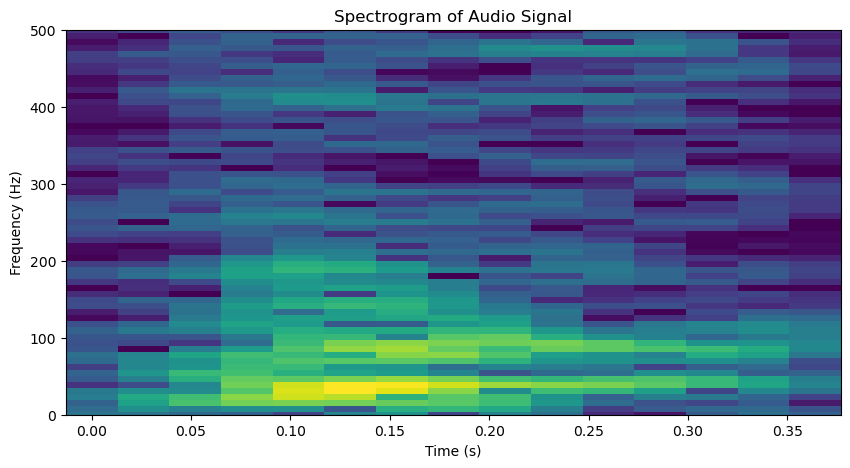

571


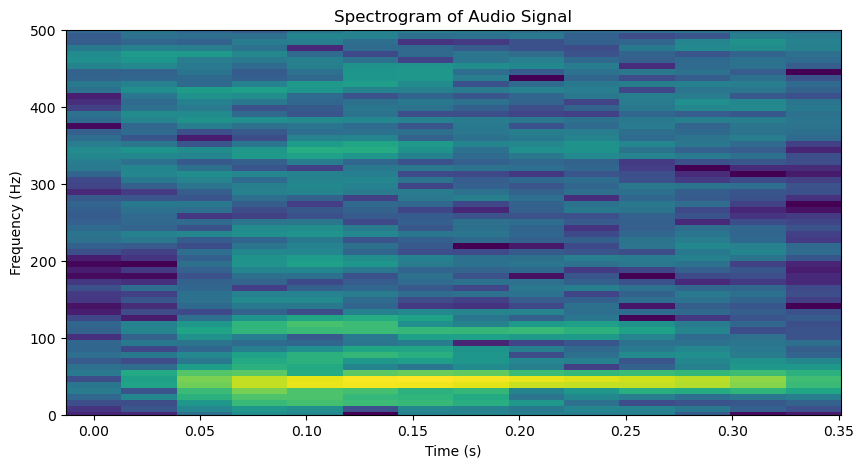

0.14666372826534488
0
0
51713.5319375


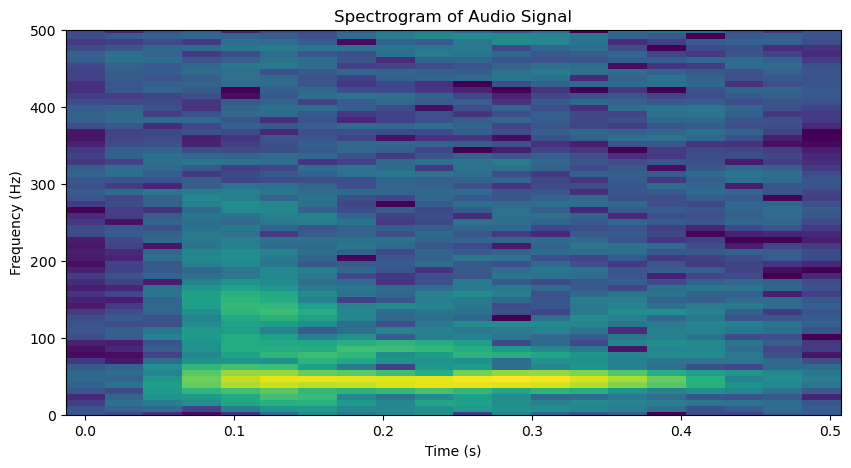

0.1543413523958365
1
1
68032.2519375


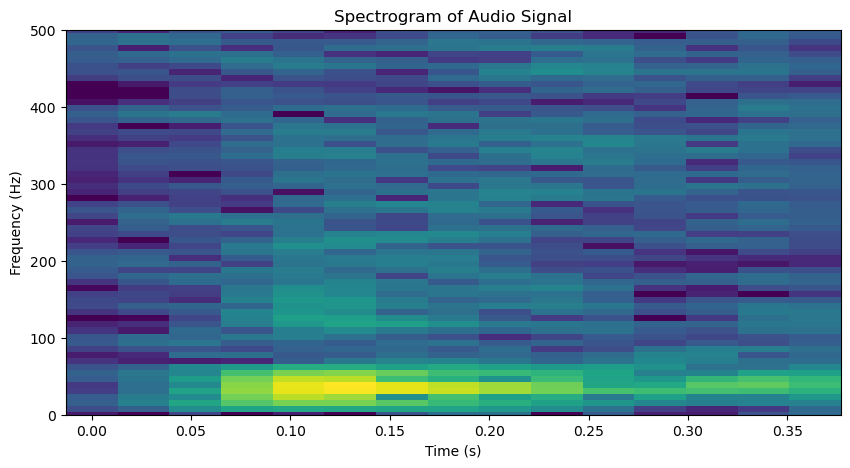

0.12124137567673209
2
2
68071.5159375


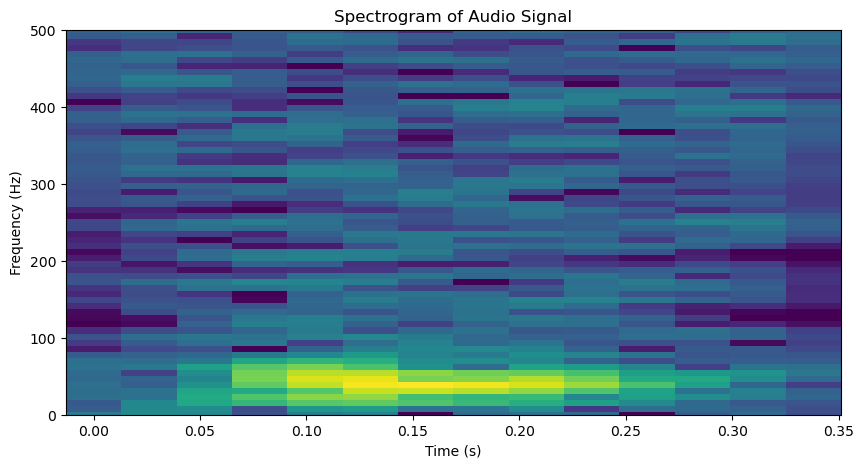

0.12438443283078095
3
3
68132.1239375


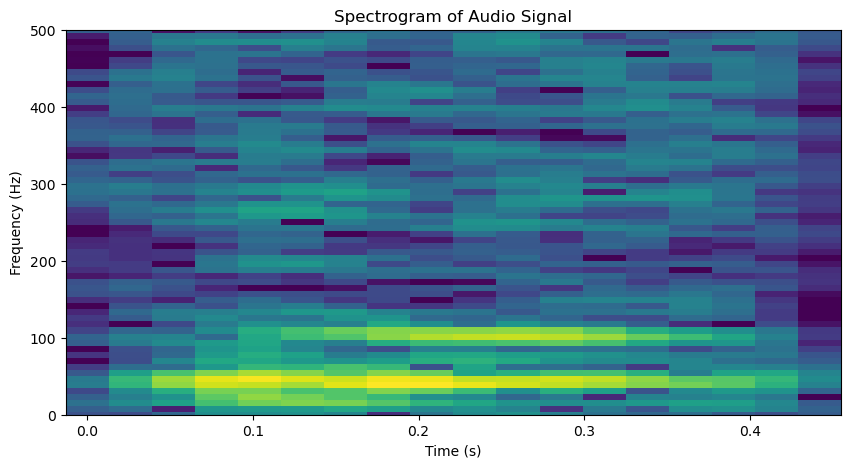

0.1273682681143593
4
4
75273.49993749999


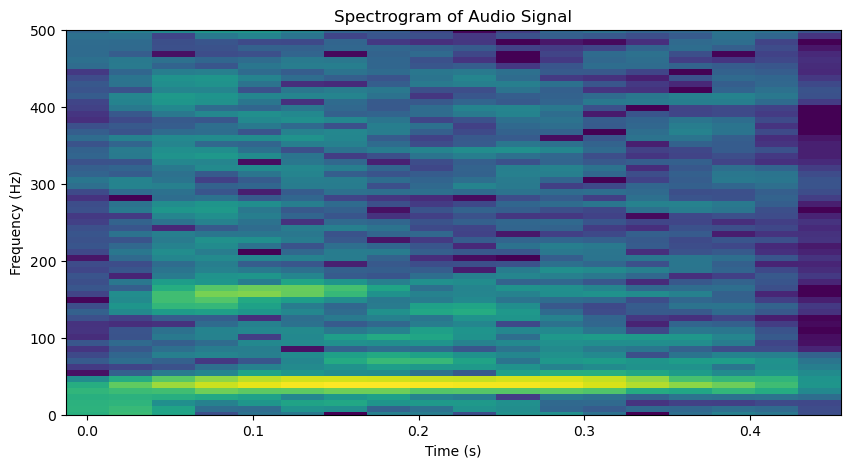

0.13480407066892464
5
5
75495.41993749999


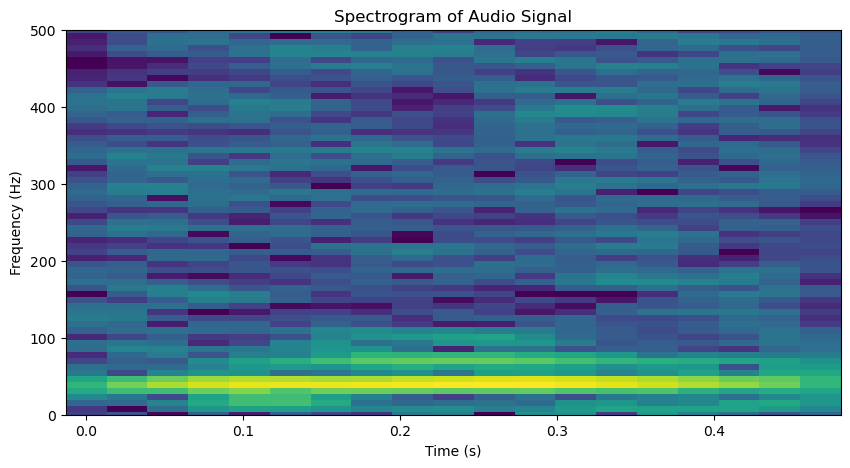

0.1429327585990502
6
6
76653.0199375


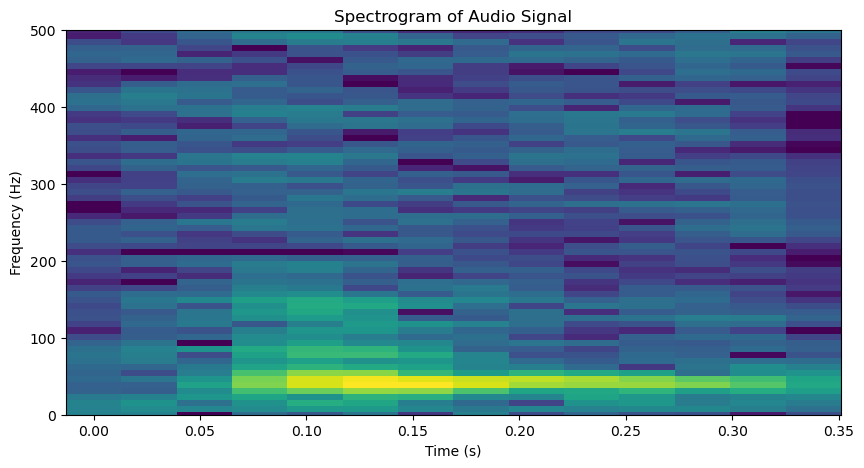

0.12539499095741866
7
7
130687.06793749999


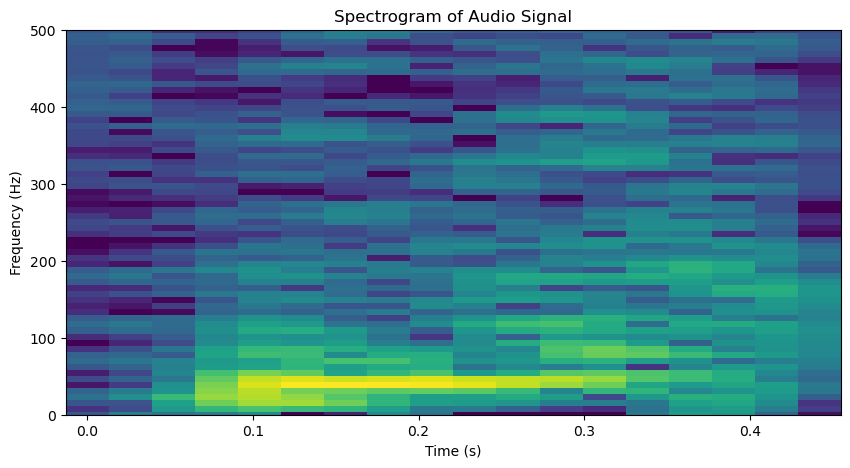

0.10337075673701758
8
8
133993.30793749998


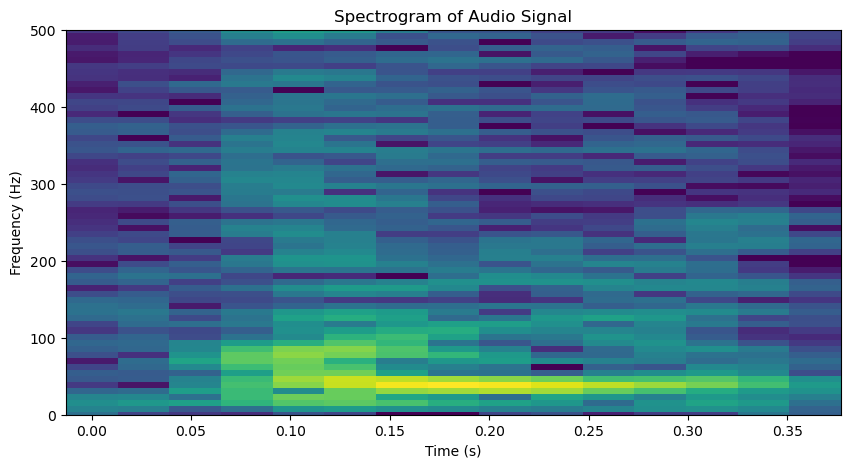

0.10410538664363306
9
9
134070.8119375


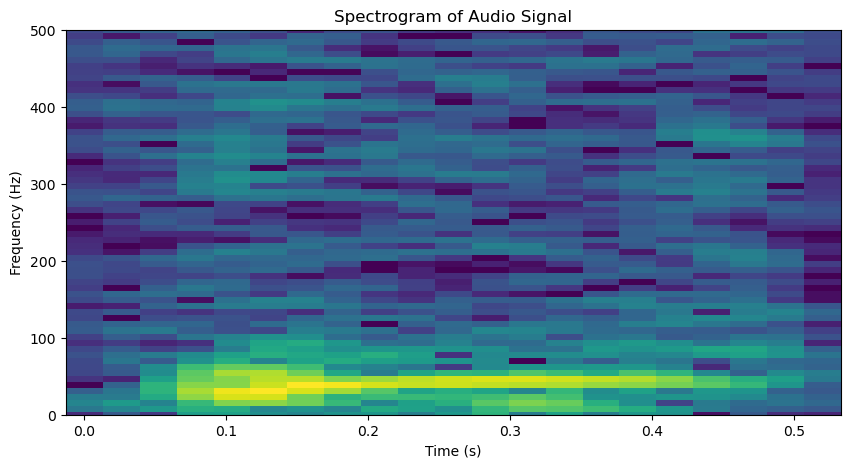

0.10665078420981317
10
10
134325.9479375


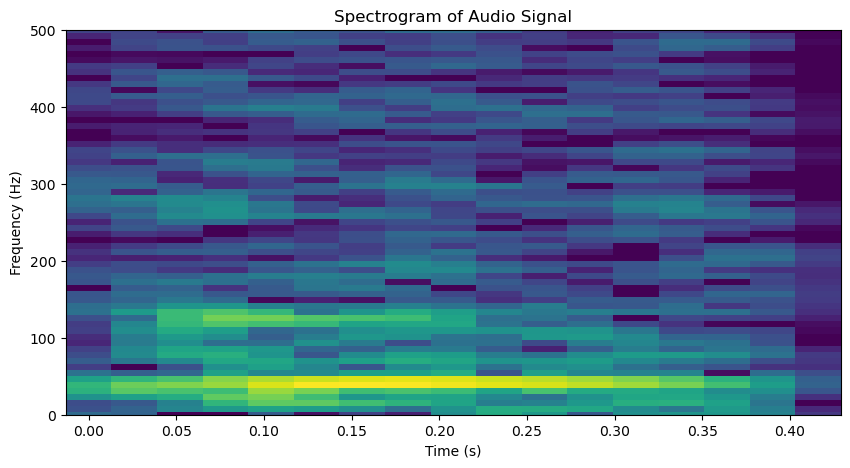

0.1253143173195939
11
11
134626.1079375


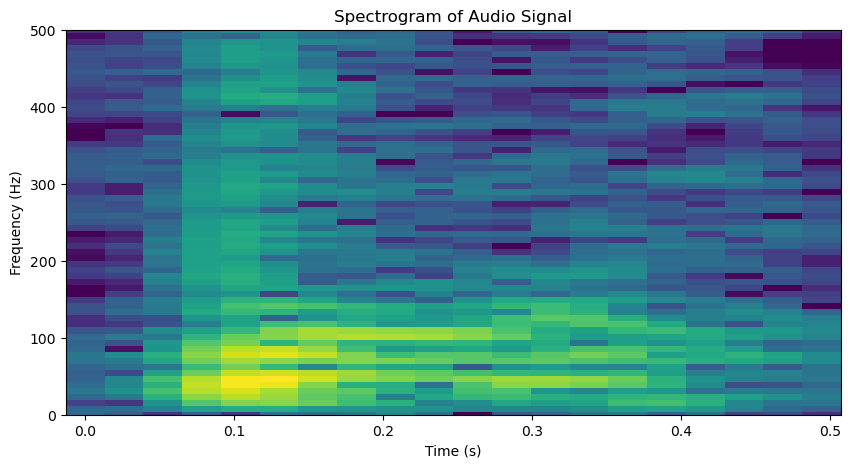

0.1297308946252096
12
12
134712.9559375


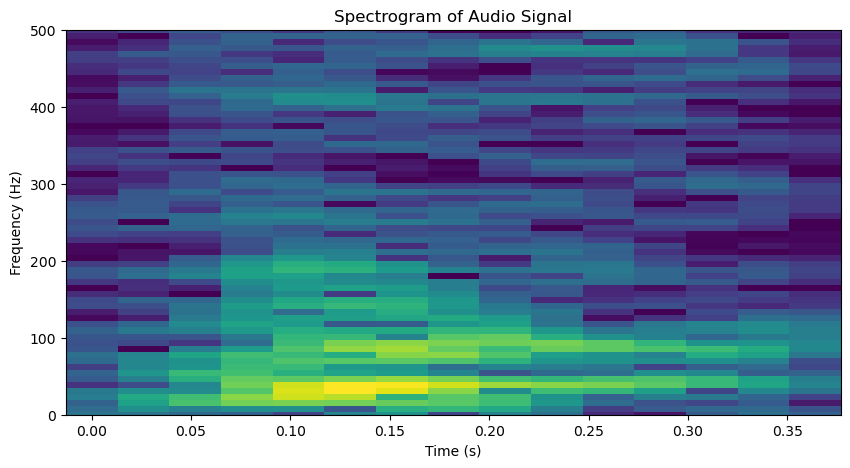

1.1102230246251566e-17
13
13
134740.8599375


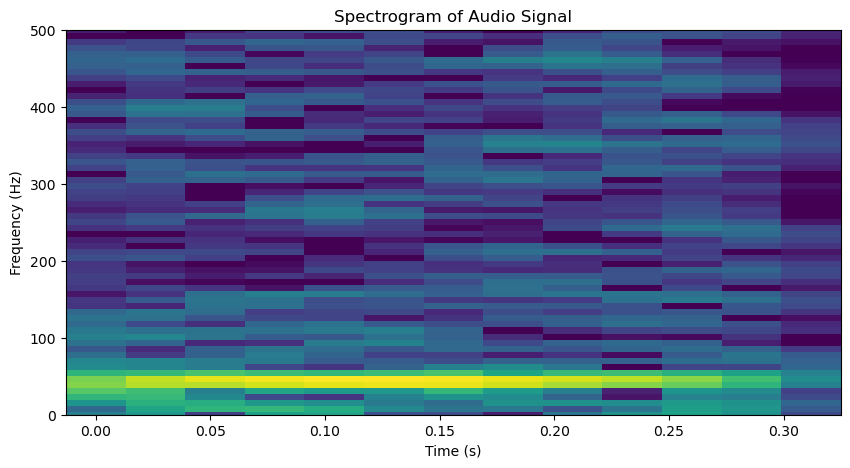

0.16587356013829924
14
14
134912.18793749998


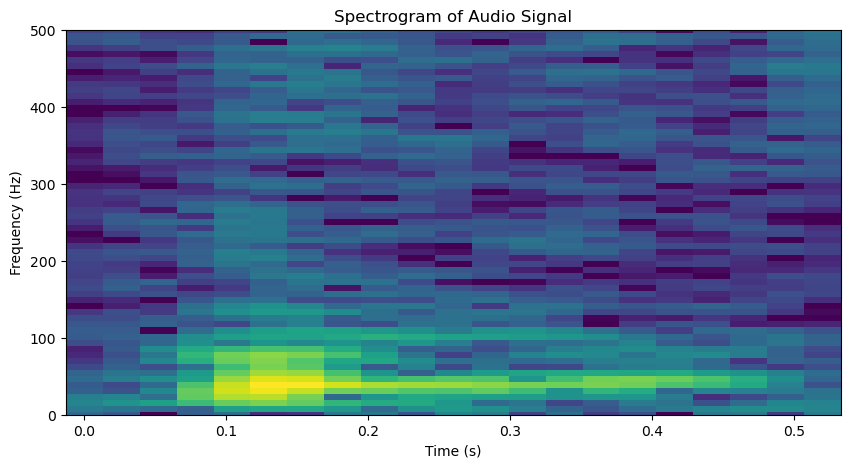

0.10041734904947976
15
15
134932.76393749999


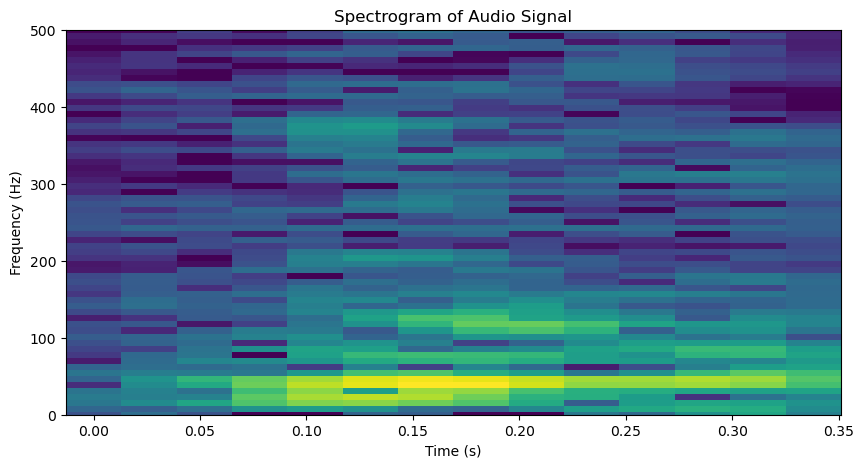

0.08991218887880188
16
16
138483.7719375


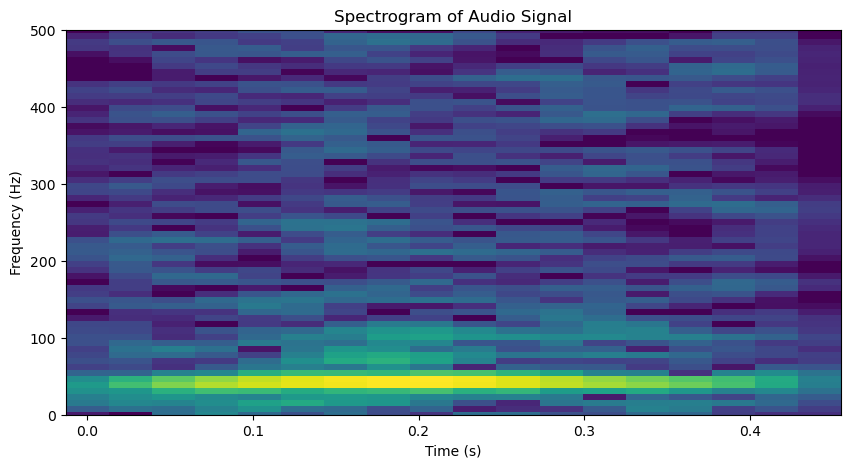

0.14897451252601454
17
17
143045.0839375


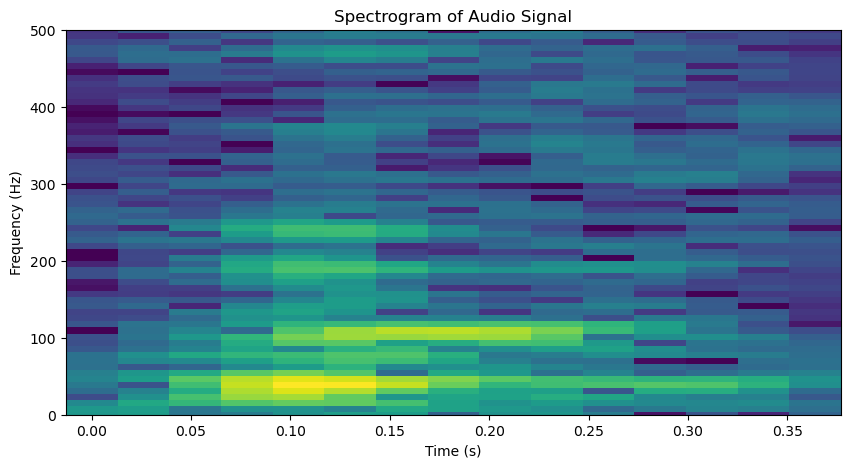

0.09992855577078588
18
18
144677.0199375


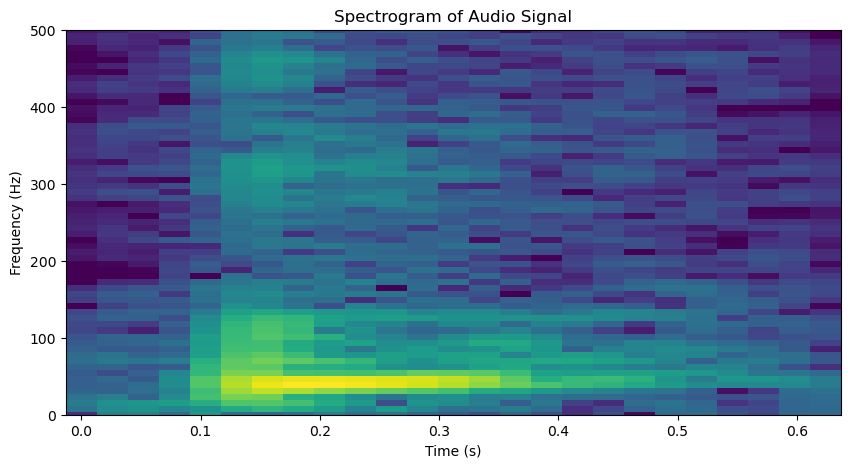

0.12904738121092074
19
19
146604.8599375


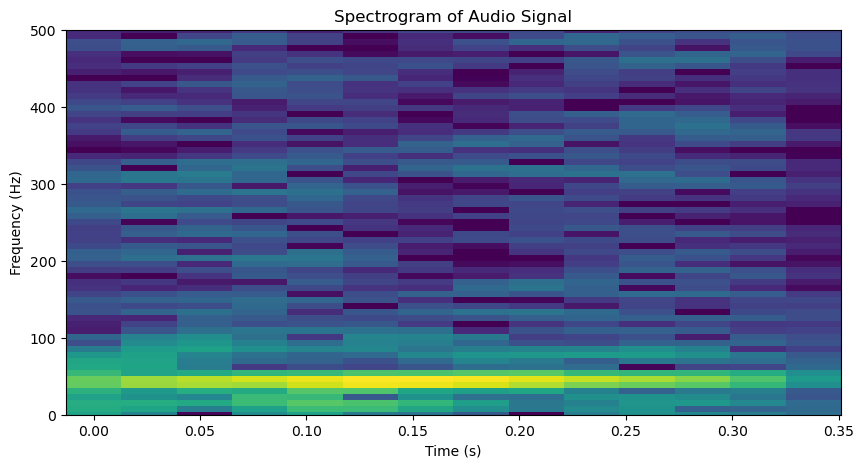

0.15095753958976807
20
20
146669.2119375


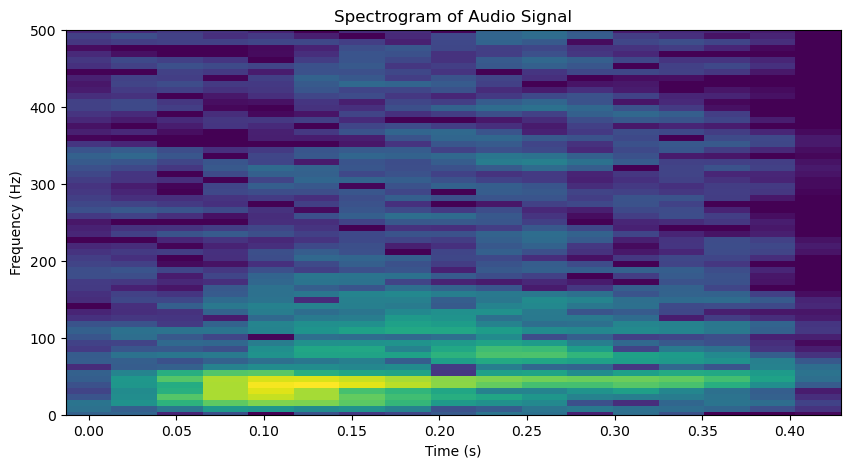

0.09864204190425137
21
21
146754.2679375


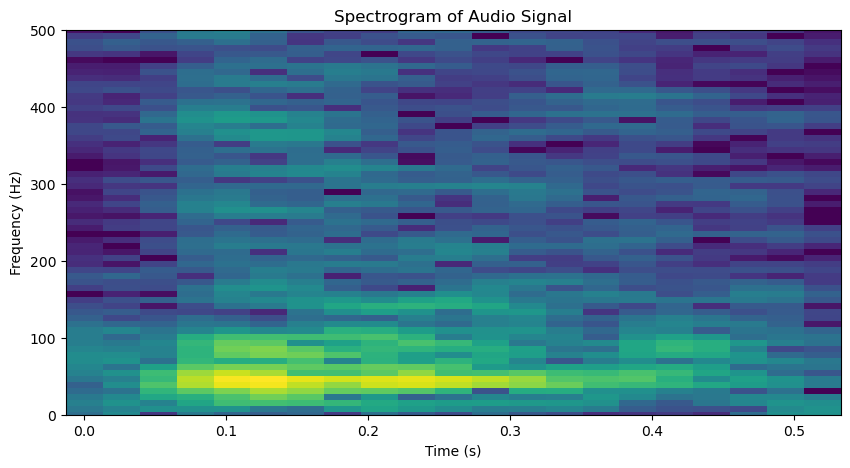

0.13020421262384424
22
22
146783.32393749998


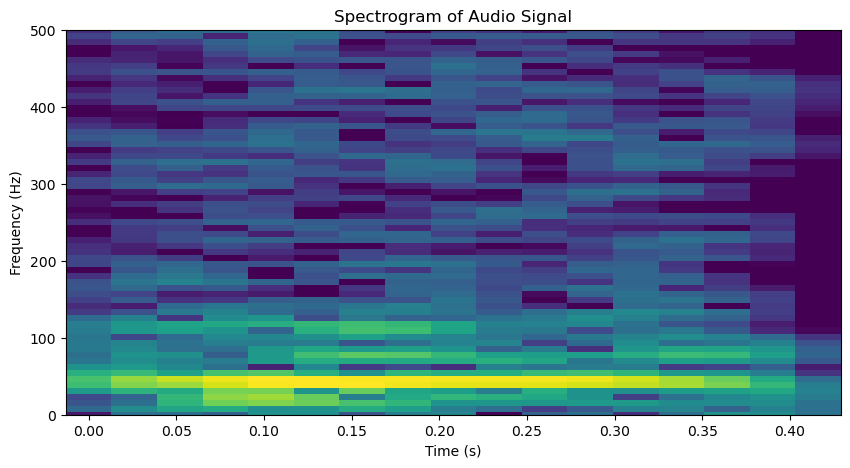

0.12803275690417687
23
23
146870.3959375


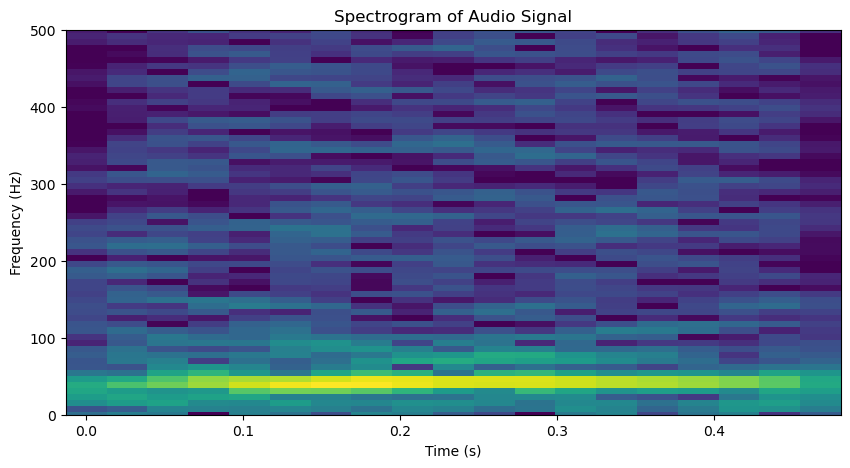

0.14510430968958646
24
24
147054.9079375


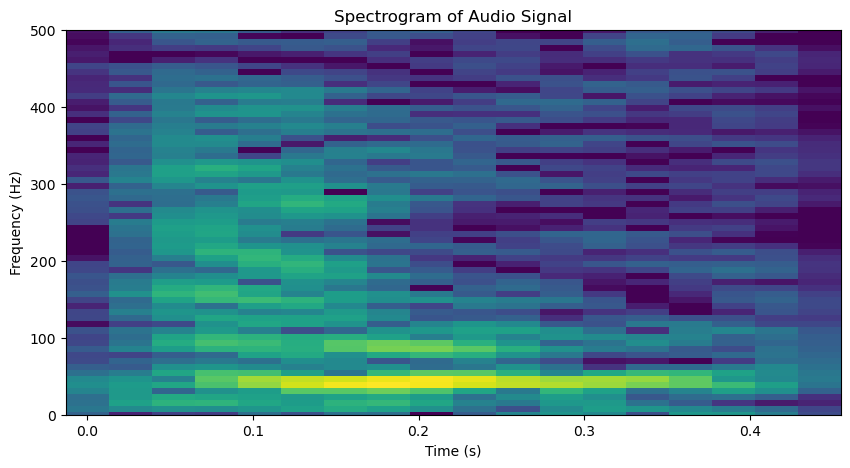

0.1221937071859871
25
25
147081.9479375


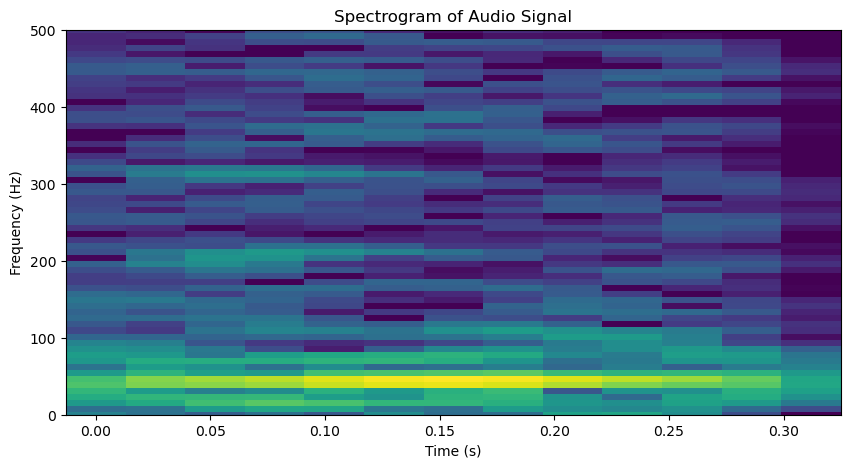

0.13802177928083473
26
26
147145.46793749998


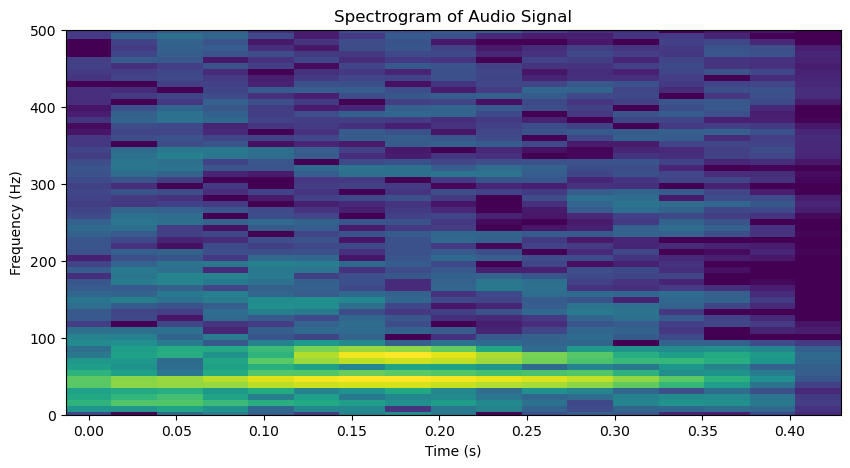

0.1387945797639527
27
27
147180.9559375


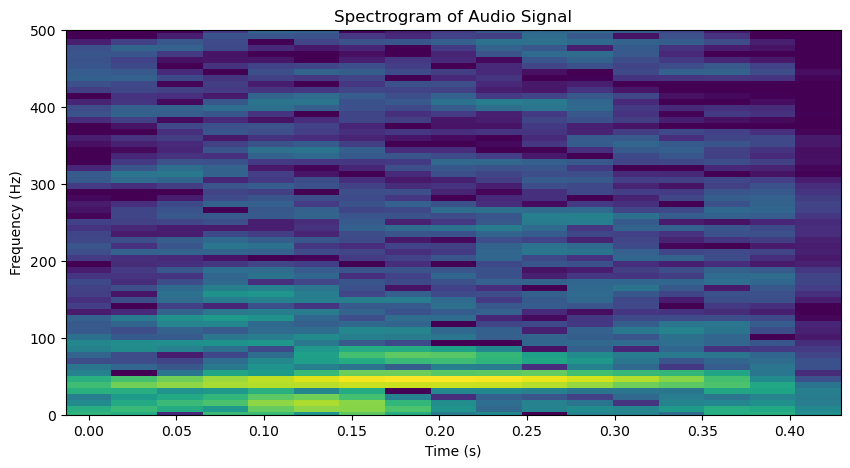

0.1620469398470744
28
28
147218.2999375


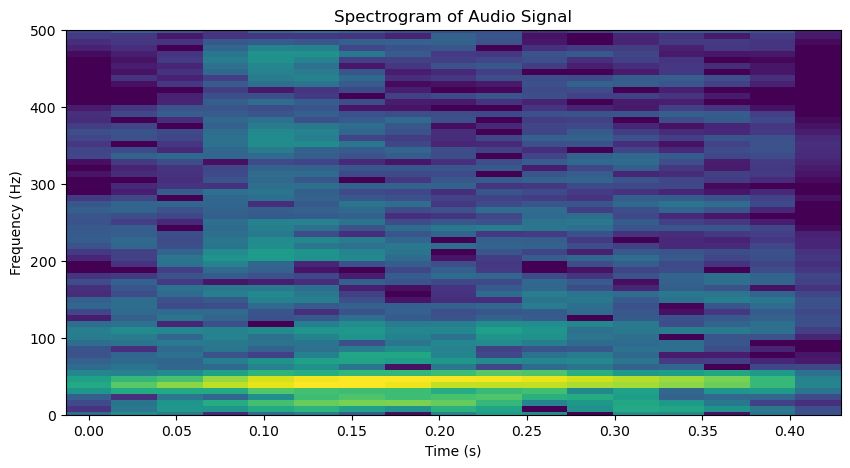

0.14692935739288993
29
29
147440.89193749998


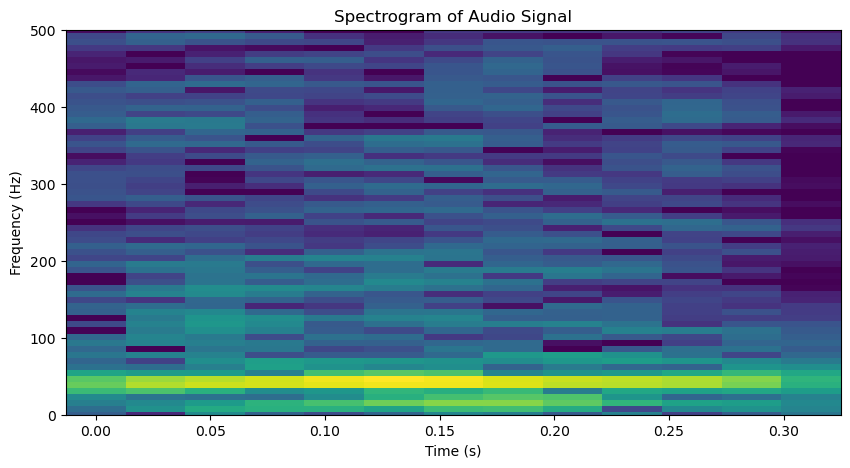

0.16428956601790068
30
30
147593.46793749998


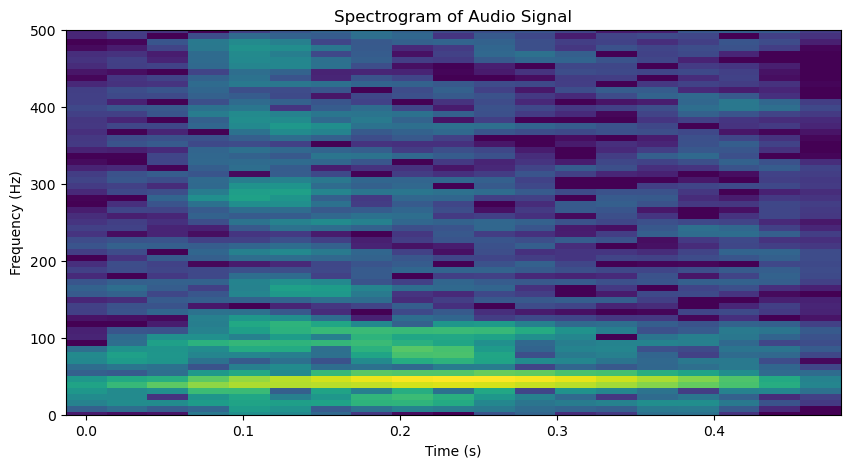

0.12645432058141604
31
31
147663.4839375


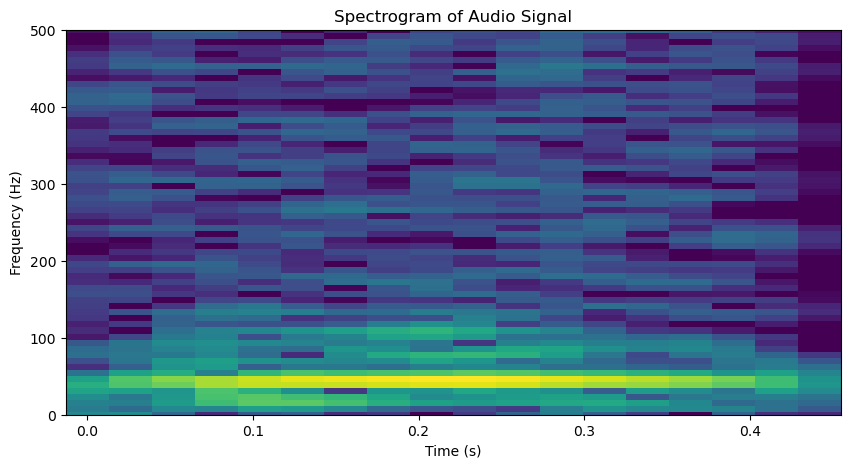

0.148745451250119
32
32
147720.7959375


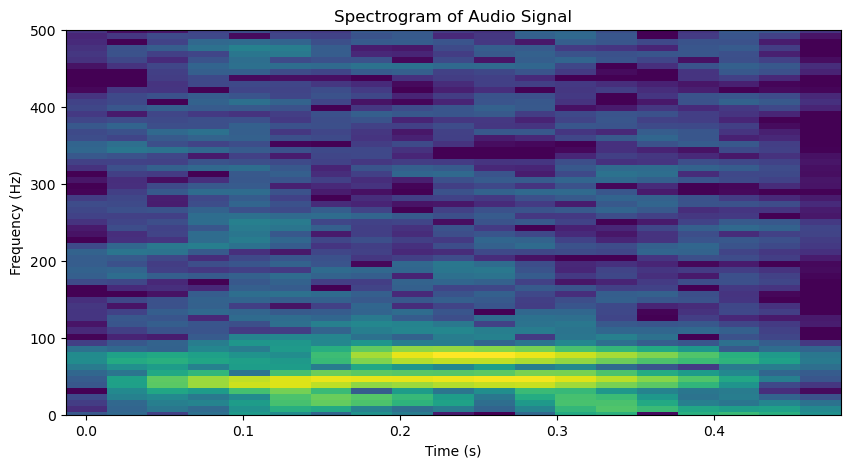

0.15370263081292698
33
33
147781.30793749998


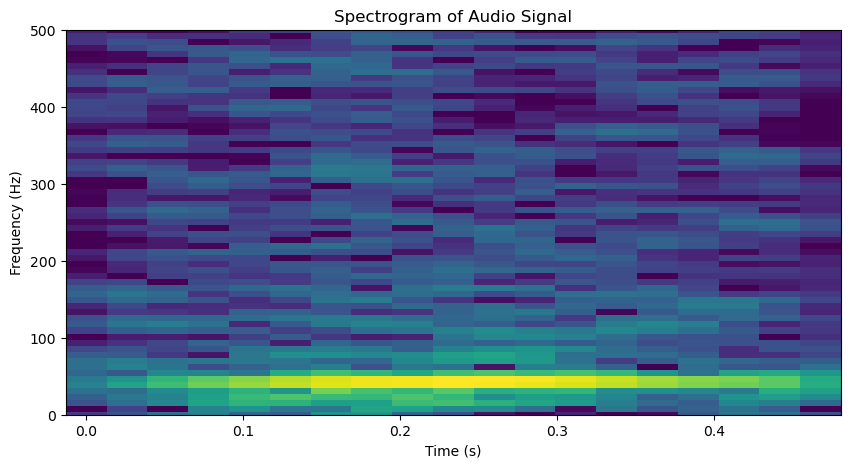

0.14888726647297582
34
34
148103.32393749998


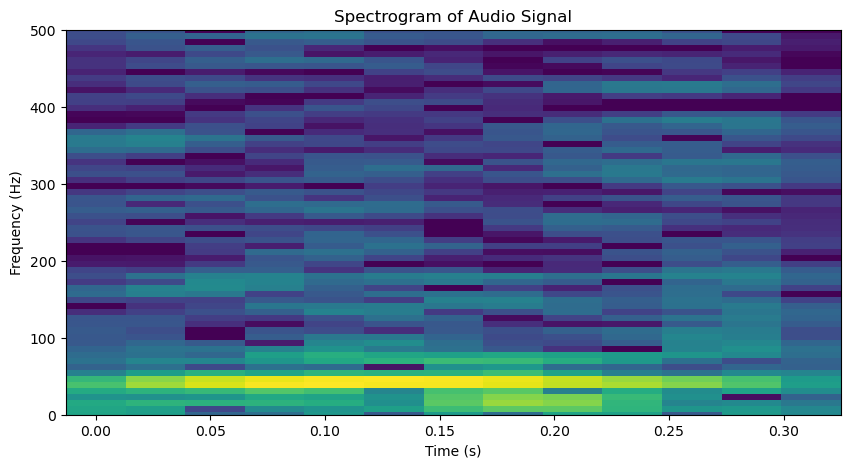

0.1363644184859596
35
35
150208.31593749998


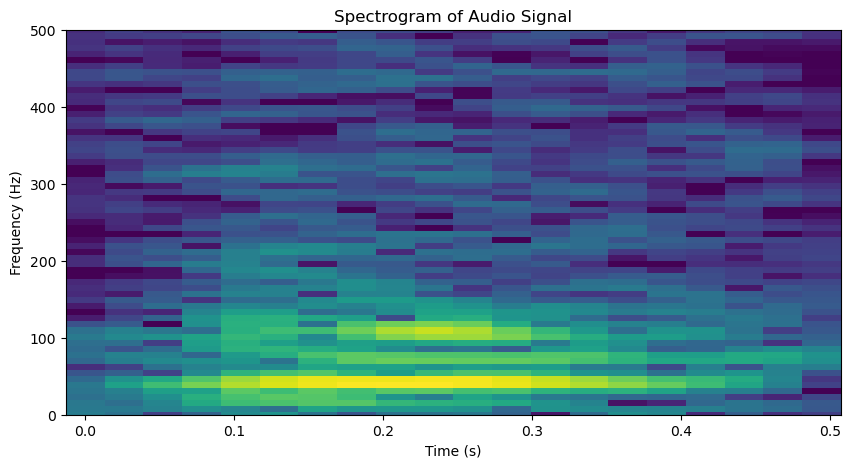

0.12018068532774667
36
36
150403.9959375


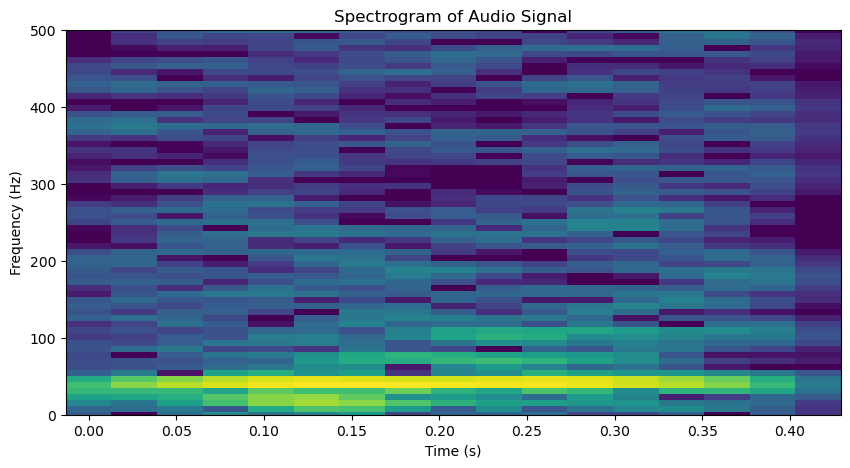

0.13122699359167989
37
37
150458.2359375


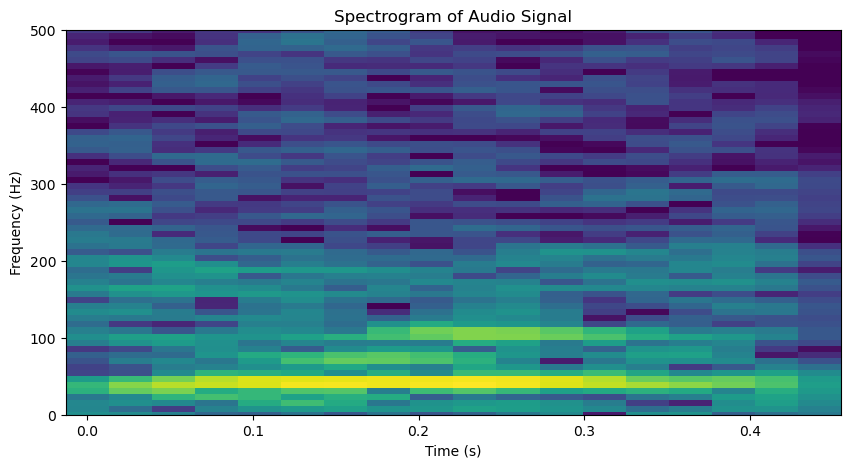

0.1389707257851254
38
38
150481.9159375


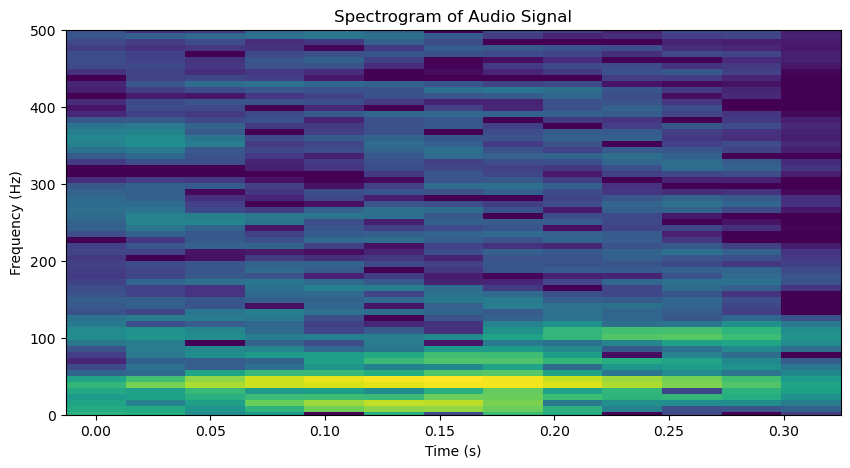

0.13287686141707428
39
39
150513.4999375


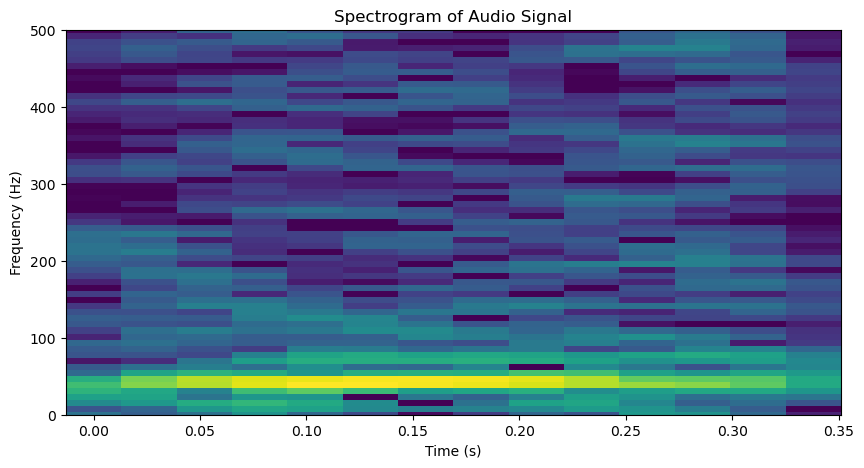

0.1408014177617837
40
40
150753.5319375


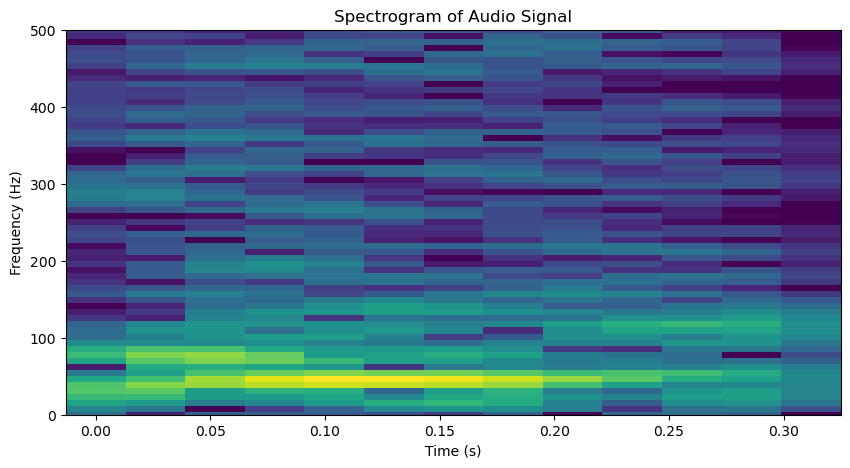

0.13934509672480513
41
41
150806.9719375


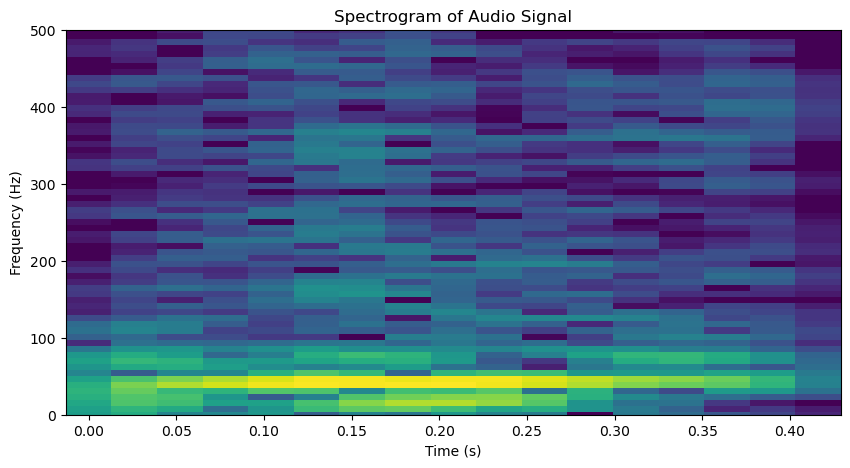

0.11982781018188866
42
42
150827.6759375


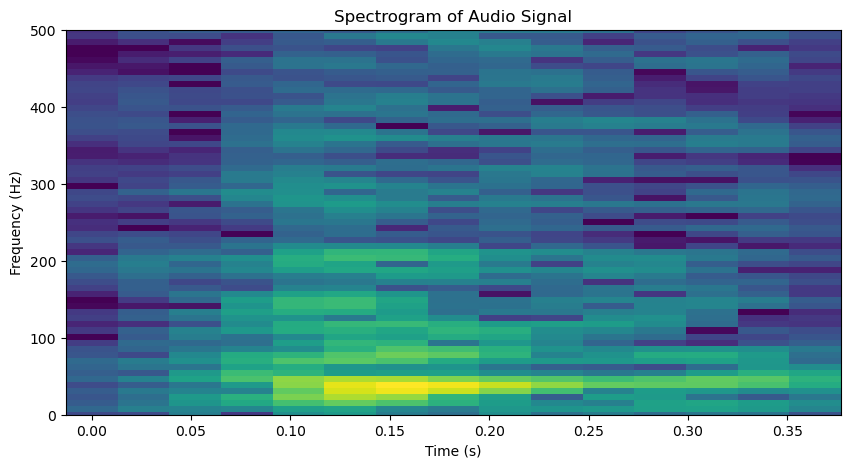

0.08420583911440807
43
43
150978.17193749998


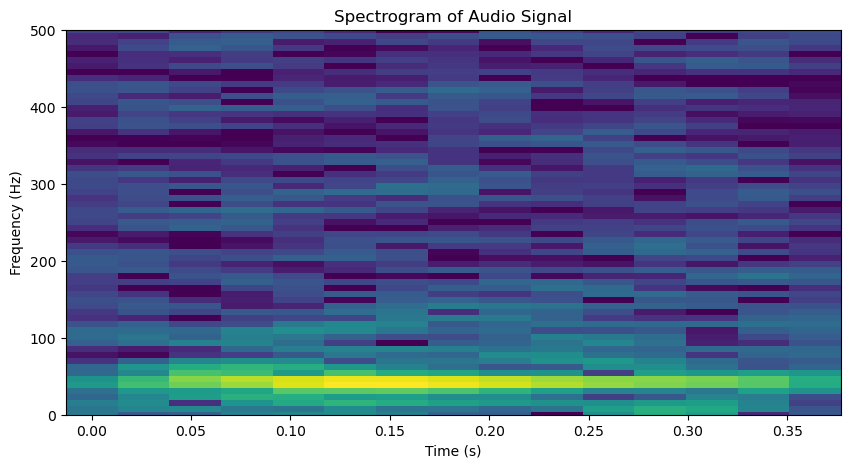

0.1337759515041298
44
44
151001.2439375


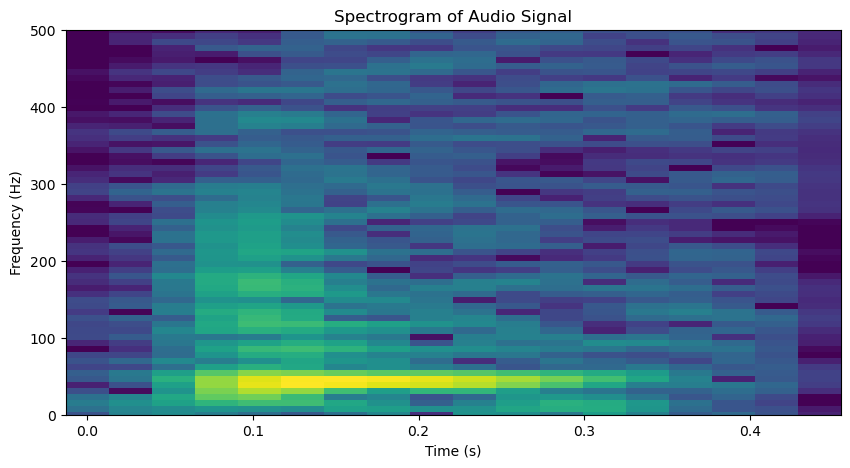

0.13458361715172013
45
45
151033.5639375


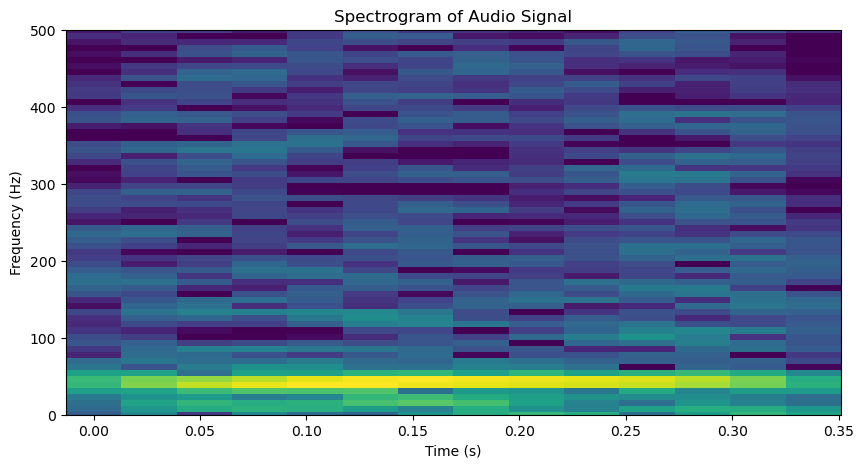

0.14628015279392825
46
46
151046.9399375


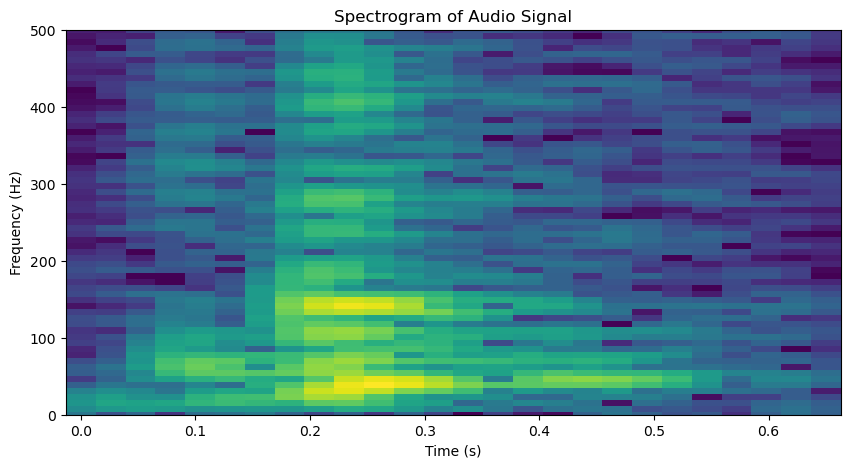

0.13752893246789225
47
47
151064.5399375


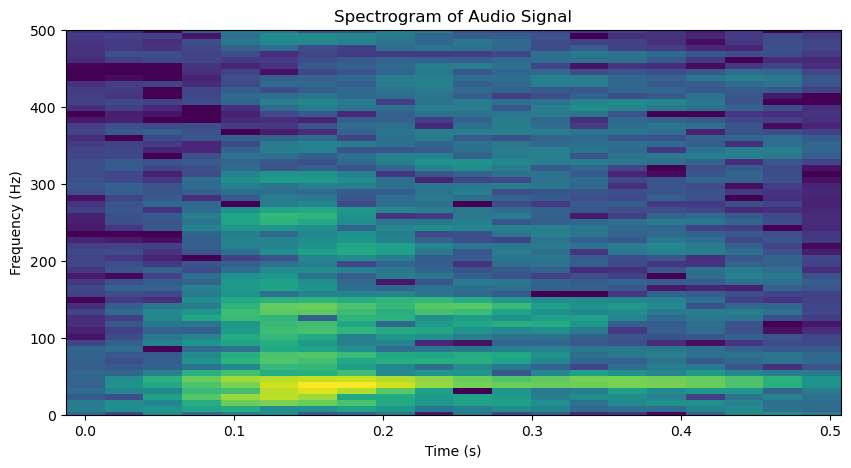

0.11159208880631923
48
48
151118.3639375


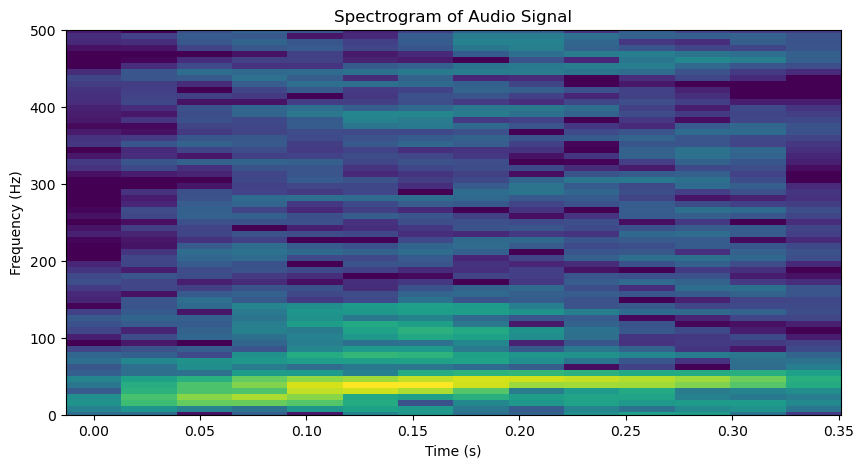

0.10577897218070292
49
49
151138.9079375


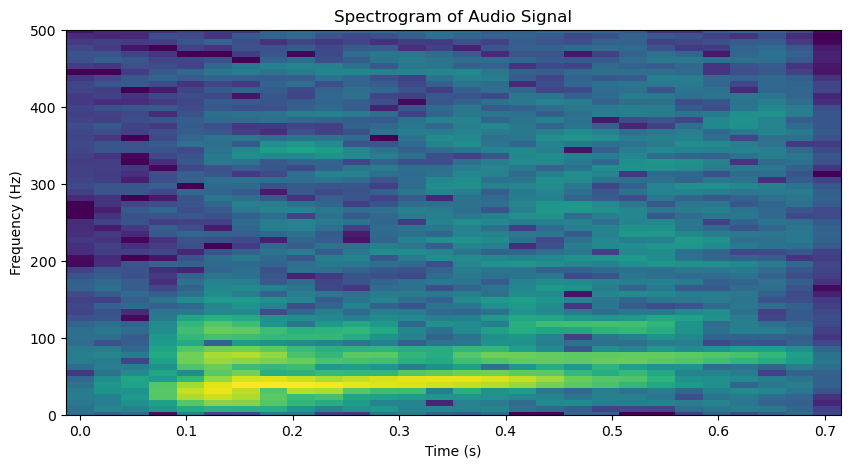

0.13790250227854697
50
50
151139.6439375


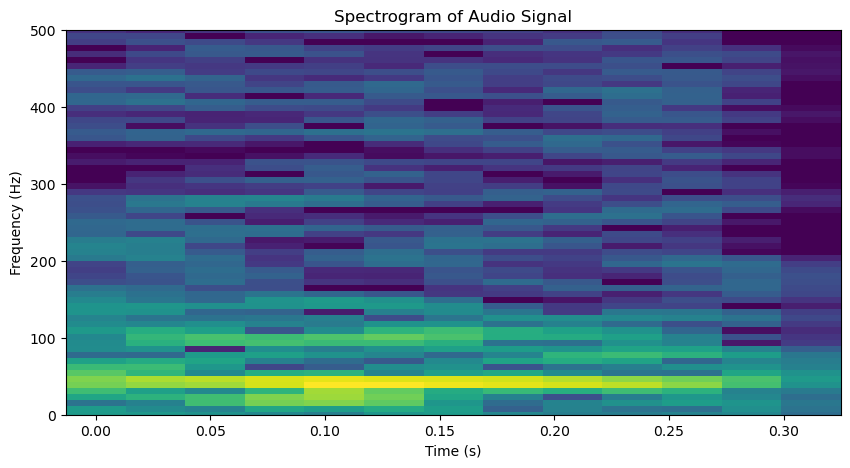

0.11503078316561824
51
51
151159.1639375


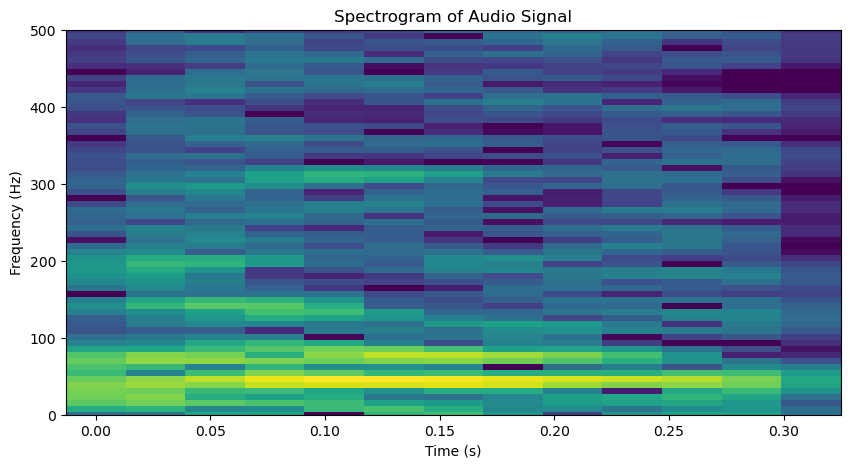

0.12246278319347739
52
52
151170.7159375


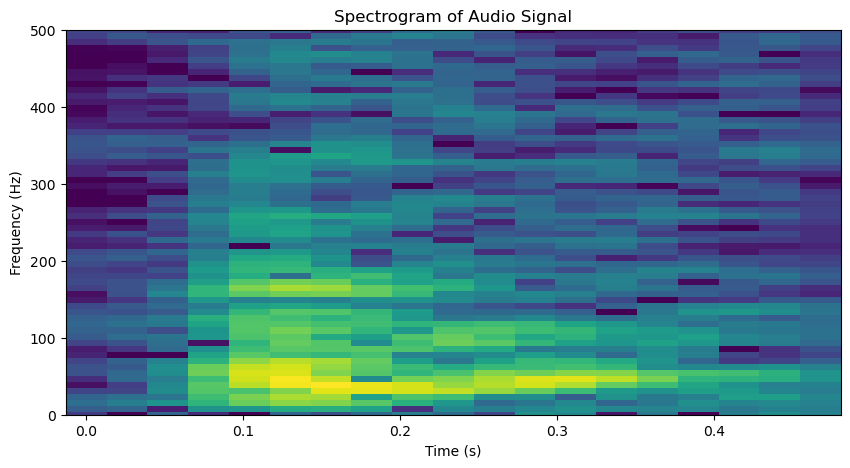

0.11777081626201664
53
53
151179.32393749998


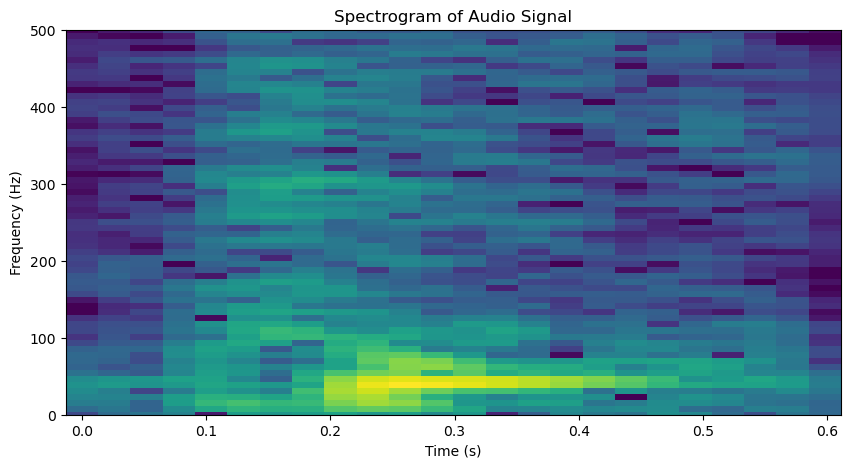

0.13749366447382458
54
54
151180.3479375


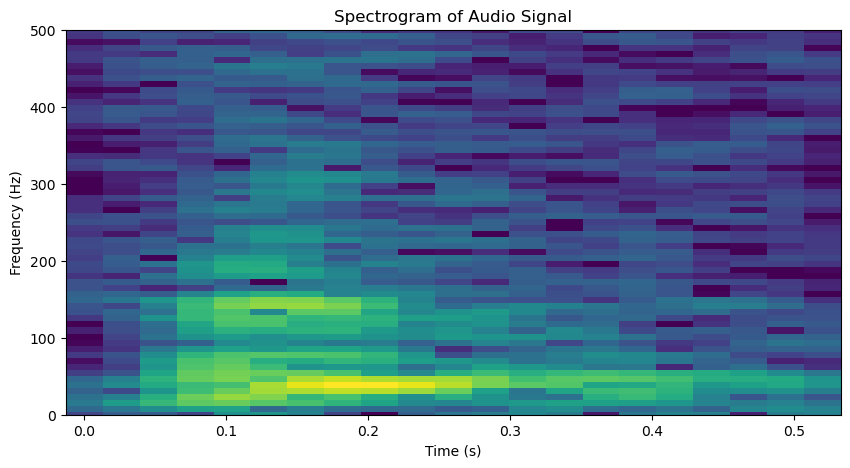

0.12258728388181869
55
55
151213.9799375


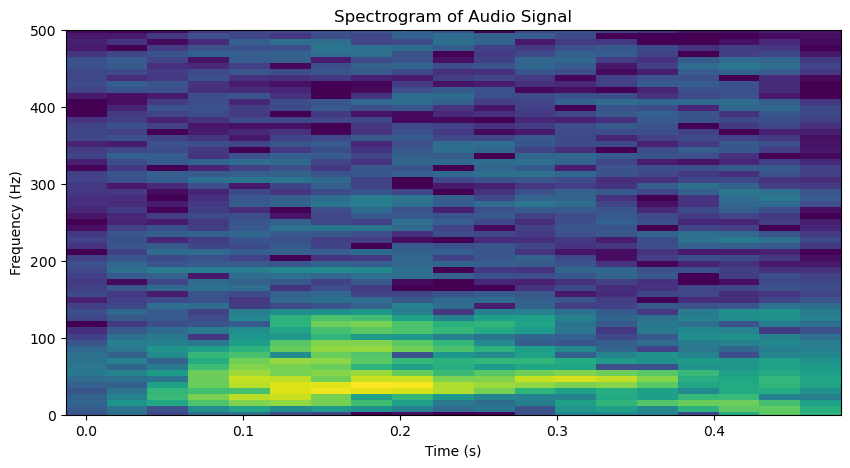

0.1170955408892634
56
56
151223.89993749998


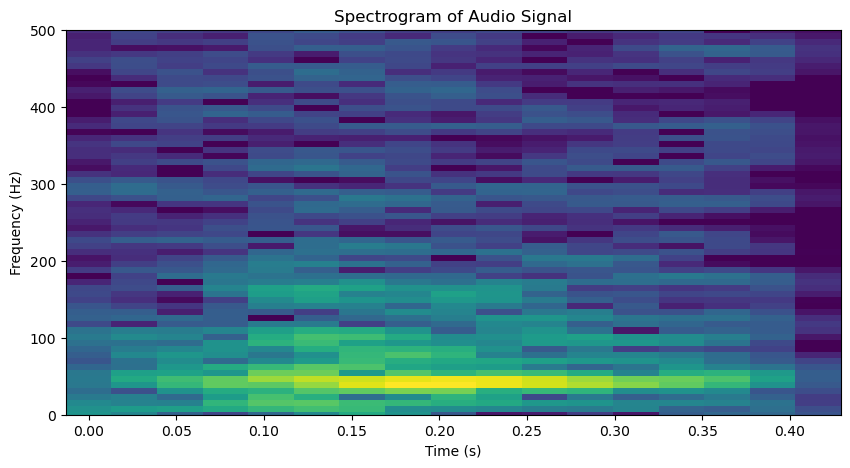

0.11862602670021129
57
57
151232.3799375


In [121]:
plot_spectrogram(f_temp, t_temp, Zxx_temp, fs_new)
print(len(oor))
for j in range(58):
    f_sig, t_sig, Zxx_sig, fs_new = short_time_calc(whale_call_segments[oor[j]], f_s)
    plot_spectrogram(f_sig, t_sig, Zxx_sig, fs_new)
    plt.show()
    dtw_cost = DTW_calc(Zxx_temp, Zxx_sig)
    print(dtw_cost)
    print(j)
    print(oor[j])
    print(start_t_temp[oor[j]])


Running loop for comparison

In [ ]:
stft_cost = []
for i in range(100):
    audio_seg = audio_segments[i]
    f_temp, t_temp, Zxx_temp, fs_new = short_time_calc(audio_template_1, f_s)
    f_seg, t_seg, Zxx_seg, fs_new = short_time_calc(audio_seg, f_s)
    stft_cost.append(DTW_calc(Zxx_temp, Zxx_seg))
    #print(i)
